# EXERCISE - Counting objects workflow (batch)

---
*Introduction to Image Analysis Workshop*

*Stefania Marcotti (stefania.marcotti@crick.ac.uk)*

*Intro to building batch image analysis pipelines with Python*

*CC-BY-SA-4.0 license: creativecommons.org/licenses/by-sa/4.0/*

---

Following on from the previous [notebook](https://github.com/RMS-DAIM/introduction-to-image-analysis/tree/main/Scripts/Jupyter/counting_objects.ipynb), we run the same pipeline on all the images available in the [`Data/idr0028`](https://github.com/RMS-DAIM/introduction-to-image-analysis/tree/main/Data/idr0028) folder. 

Fill in the gaps `[...]` in the notebook and look at the Tasks as you go through to achieve the batch analysis. Solutions are available in the Scripts folder, but please give it a good try first! Also, try not to use ChatGPT or other LLMs (but Google is allowed!)

### Import libraries

Note we are importing also the library `os` (API [here](https://docs.python.org/3/library/os.html)) which provides miscellaneous operating system interfaces.

In [12]:
import os

import numpy as np

from skimage import io
from skimage import filters
from skimage import measure

import matplotlib.pyplot as plt

import pandas as pd

### Import data
This time we are reading all of the files in the folder - note the use of the wildcard `*`!

In [13]:
# get the list of all files and directories
path = '../../Data/idr0028/'
dir_list = os.listdir(path)

print(*dir_list, sep='\n')

003003-10.tif
003003-11.tif
003003-12.tif
003003-13.tif
003003-14.tif
003003-15.tif
003003-16.tif
003003-17.tif
003003-18.tif
003003-19.tif


In [14]:
# read all .tif files in folder
im_read = io.imread('../../Data/idr0028/*.tif')

In [15]:
# check the dimensions of the object
print('Object dimensions:', im_read.shape)

Object dimensions: (10, 501, 667, 4)


<div style="background-color:#abd9e9; border-radius: 5px; padding: 10pt"><strong>Task</strong> The image dimensions are currently in the (n, y, x, c) format. Ideally, by convention, we would want the dimensions of the image to be (n, c, x, y). We can rearrange the dimensions by using the numpy function <code>transpose</code>.</div>

In [25]:
im_all = np.transpose(im_read, (0, 3, 1, 2))
print('New object dimensions:', im_all.shape)

New object dimensions: (10, 4, 501, 667)


<div style="background-color:#abd9e9; border-radius: 5px; padding: 10pt"><strong>Task</strong> We can visualise some example nuclear images by running the cell below. The variable <code>im_idx</code> indicates which image we want to open (first=0, second=1, ...); how do we select the correct image from <code>im_all</code>?</div>

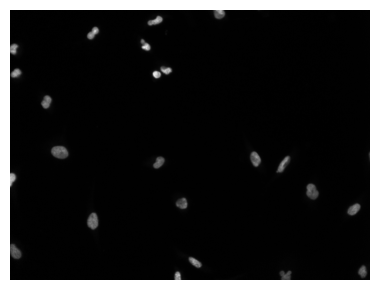

In [37]:
# select image
im_idx = 0
ch_idx = 0 #channels
im = im_all[im_idx,ch_idx,]

#nuclear channel of each image
# display the chosen image
fig, ax = plt.subplots(figsize=(4,3))
ax.imshow(im, cmap='gray')
ax.axis('off')
plt.tight_layout()

### Perform the analysis on one image at the time

<div style="background-color:#abd9e9; border-radius: 5px; padding: 10pt"><strong>Task</strong> By using a <code>for</code> loop, we can open one image at the time, and perform the same exact pipeline as before to count the objects and measure their area and eccentricity. We can use the numpy function <code>append</code> to save the results for object count in an array called <code>obj_count</code> and create a pandas dataframe called <code>props_df</code> where each row represents one object and each column one measurement (hint! You might need the pandas function <code>concat</code> with the flag <code>ignore_index=True</code>).</div>

In [38]:
for im_idx in range(10):
    print("Image index (loop around):" , im_idx)

Image index (loop around): 0
Image index (loop around): 1
Image index (loop around): 2
Image index (loop around): 3
Image index (loop around): 4
Image index (loop around): 5
Image index (loop around): 6
Image index (loop around): 7
Image index (loop around): 8
Image index (loop around): 9


In [39]:
# initialise output
obj_count = []
props_df = pd.DataFrame()

# set up for loop for all the images available in the folder
for im_idx in range(im_all.shape[0]):
    #select image
    im = im_all[im_idx,0,]
    #select filter
    im_gauss = filters.gaussian(im, sigma=5)
    #select threshold
    thresh = filters.threshold_otsu(im_gauss)
    im_thresh = im_gauss >= thresh
    #count labels 
    labels = measure.label(im_thresh)
    #count object 
    obj_count = np.append(obj_count,labels.max())
    #properties 
    props = measure.regionprops_table(labels, im, properties=['label', 'area', 'eccentricity'])
    props_df = pd.DataFrame(props)
    #image D
    props['image_ID'] = dir_list[im_idx]
    # add to output dataframe
    props_df = pd.concat([props_df, pd.DataFrame(props)], ignore_index=True)
    

In [40]:
# print output [obj_count]
print('The number of nuclei for each image is:', obj_count)

The number of nuclei for each image is: [22. 22. 20. 31. 31. 30. 23.  9. 21. 36.]


In [41]:
for im_idx in range(im_all.shape[0]):
    print('The number of nuclei in', dir_list[im_idx], 'is', obj_count[im_idx])

The number of nuclei in 003003-10.tif is 22.0
The number of nuclei in 003003-11.tif is 22.0
The number of nuclei in 003003-12.tif is 20.0
The number of nuclei in 003003-13.tif is 31.0
The number of nuclei in 003003-14.tif is 31.0
The number of nuclei in 003003-15.tif is 30.0
The number of nuclei in 003003-16.tif is 23.0
The number of nuclei in 003003-17.tif is 9.0
The number of nuclei in 003003-18.tif is 21.0
The number of nuclei in 003003-19.tif is 36.0


In [42]:
# show the beginning of the properties dataframe
props_df.head()

,label,area,eccentricity,image_ID
0,1,435.0,0.399736,NaN
1,2,688.0,0.471042,NaN
2,3,391.0,0.728290,NaN
3,4,386.0,0.781994,NaN
4,5,441.0,0.743003,NaN


In [43]:
# how many nuclei did we analyse?
print('We analysed', len(props_df), 'nuclei in', im_all.shape[0], 'images')

We analysed 72 nuclei in 10 images


### Plot some results

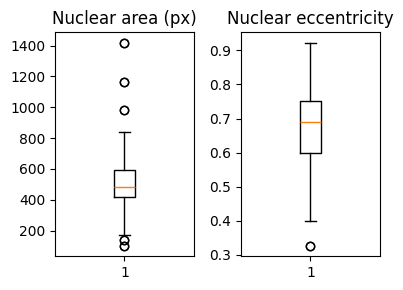

In [44]:
fig, axs = plt.subplots(1, 2, figsize=(4,3))

axs[0].boxplot(props_df['area'])
axs[0].set_title('Nuclear area (px)')

axs[1].boxplot(props_df['eccentricity'])
axs[1].set_title('Nuclear eccentricity')

plt.tight_layout()

### Save outputs

<div style="background-color:#abd9e9; border-radius: 5px; padding: 10pt"><strong>Task</strong> We can save the <code>props_df</code> dataframe as an Excel file with the pandas function <code>to_excel</code>.</div>

In [45]:
# save dataframe as excel file
props_df.to_excel('../../Data/idr0028/results_jupyterbatchex.xlsx')

<div style="background-color:#c1c3d7; border-radius: 5px; padding: 10pt"><strong>Task (difficult!)</strong> We can save the label images using a function called <code>imsave</code> inside the <code>skimage.io</code> module. This will require setting up another <code>for</code> loop and think of a way to work with output file names. Give it a go!</div>

In [47]:
# save label images
for im_idx in range(im_all.shape[0]):
    # open image (only ch0)
    im = im_all[im_idx,0,]
    # filter with Gaussian
    im_gauss = filters.gaussian(im, sigma=5)
    # threshold with Otsu
    thresh = filters.threshold_otsu(im_gauss)
    im_thresh = im_gauss >= thresh
    # label mask
    labels = measure.label(im_thresh)
    # save
    file_name = '../../Data/idr0028/results_jupyterbatchex.xlsx'+dir_list[im_idx][0:-4]+'_labels.tif'
    io.imsave(file_name, labels)

C:\Users\CSC\anaconda3\envs\IAworkshop-env\lib\site-packages\skimage\_shared\utils.py:328: UserWarning: ../../Data/idr0028/results_jupyterbatchex.xlsx003003-10_labels.tif is a low contrast image
  return func(*args, **kwargs)
C:\Users\CSC\anaconda3\envs\IAworkshop-env\lib\site-packages\skimage\_shared\utils.py:328: UserWarning: ../../Data/idr0028/results_jupyterbatchex.xlsx003003-11_labels.tif is a low contrast image
  return func(*args, **kwargs)
C:\Users\CSC\anaconda3\envs\IAworkshop-env\lib\site-packages\skimage\_shared\utils.py:328: UserWarning: ../../Data/idr0028/results_jupyterbatchex.xlsx003003-12_labels.tif is a low contrast image
  return func(*args, **kwargs)
C:\Users\CSC\anaconda3\envs\IAworkshop-env\lib\site-packages\skimage\_shared\utils.py:328: UserWarning: ../../Data/idr0028/results_jupyterbatchex.xlsx003003-13_labels.tif is a low contrast image
  return func(*args, **kwargs)
C:\Users\CSC\anaconda3\envs\IAworkshop-env\lib\site-packages\skimage\_shared\utils.py:328: UserW

### Further reading
If you're interested in knowing more about image analysis in Python, there are a lot of free resources out there! One good starting point is the [IAFIG-RMS Python for Bioimage Analysis Course](https://github.com/RMS-DAIM/Python-for-Bioimage-Analysis). Good luck with your image analysis adventures!